# HEATMAP VISUALIZATION V2

## MSCOCO

In [8]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import DataLoader

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)
import sys
import os
sys.path.append(os.path.abspath(".."))
from dataset.mscoco.mscoco_dataloader_with_imagenet_labels import (
MSCOCOEmbeddingsDatasetWithImageNetLabels,
mscoco_imagenet_collate_fn,
)

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for Bayesian search. Install with: pip install optuna") from exc

from analysis.modality_gap import compute_gap
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)

from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_mscoco_imagenet_labels
import random

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 123
seed = SEED
g = torch.Generator().manual_seed(seed)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda:1" if torch.cuda.is_available() else "cpu"
dataset_name = "mscoco_imagenet_labels"
CLIP_MODEL = "ViT-B-32"
CLIP_PRETRAINED = "laion2b_s34b_b79k"
MODEL_NAME = f"{CLIP_MODEL}___{CLIP_PRETRAINED}"
precomputed_dir = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_train2017_clip_imagenet"
precomputed_dir_test = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{MODEL_NAME}/precomputed_val2017_clip_imagenet"

### Filtering procedure
As done in the few_dimension notebook

In [9]:
ds_train = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    precomputed_dir,
    split_name="train_shard",
    return_label_name=False,
)

ds_test = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    precomputed_dir_test,
    split_name="val_shard",
    return_label_name=False,
)


def _count_labels(dataset):
    counts = {}
    for i in range(len(dataset)):
        _, _, y = dataset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


train_counts = _count_labels(ds_train)
test_counts = _count_labels(ds_test)

test_classes = set(test_counts.keys())
keep_classes = {c for c in test_classes if train_counts.get(c, 0) >= 10}

train_indices = [
    i for i in range(len(ds_train))
    if int(ds_train[i][2].item()) in keep_classes
]

test_indices = [
    i for i in range(len(ds_test))
    if int(ds_test[i][2].item()) in keep_classes
]

filtered_train = torch.utils.data.Subset(ds_train, train_indices)
filtered_test = torch.utils.data.Subset(ds_test, test_indices)


def _count_labels_subset(subset):
    counts = {}
    for i in range(len(subset)):
        _, _, y = subset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts


filtered_train_counts = _count_labels_subset(filtered_train)
filtered_test_counts = _count_labels_subset(filtered_test)

train_classes = set(filtered_train_counts.keys())
test_classes = set(filtered_test_counts.keys())

print(f"Kept classes (train >= 10 & in test): {len(keep_classes)}")
print(f"Train classes after filter: {len(train_classes)}")
print(f"Test classes after filter: {len(test_classes)}")
print(f"Train samples after filter: {len(filtered_train)}")
print(f"Test samples after filter: {len(filtered_test)}")

assert train_classes == test_classes, "Train/test class mismatch after filtering"

batch_size = 256
N_CLUSTERS_MSCOCO_IMAGENET = len(train_classes)

train_loader = DataLoader(
    filtered_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)

test_loader = DataLoader(
    filtered_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=mscoco_imagenet_collate_fn,
)

[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-B-32___laion2b_s34b_b79k/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 512)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/ViT-B-32___laion2b_s34b_b79k/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 512)
Kept classes (train >= 10 & in test): 517
Train classes after filter: 517
Test classes after filter: 517
Train samples after filter: 113777
Test samples after filter: 4963


In [10]:
# %% [code]
def get_dims_gap_imagenet(loader, max_samples=20_000, device="cuda:1"):
    """
    Compute normalized per-dimension gap:
        |mean(text_dim) - mean(vision_dim)|
    over a subset of samples.
    """
    x_sum = None
    y_sum = None
    seen = 0

    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc="Compute per-dim gap"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            b = X.shape[0]
            if x_sum is None:
                x_sum = X.sum(dim=0)
                y_sum = Y.sum(dim=0)
            else:
                x_sum += X.sum(dim=0)
                y_sum += Y.sum(dim=0)

            seen += b
            if seen >= max_samples:
                break

    mean_x = x_sum / max(seen, 1)
    mean_y = y_sum / max(seen, 1)

    gap_dim = (mean_x - mean_y).abs().detach().cpu().numpy()
    gap_dim = gap_dim / (gap_dim.max() + 1e-12)

    top_gap_idx = np.argsort(-gap_dim)
    return gap_dim, top_gap_idx

### Gap-per-dimension and subspace importance
Here we use already what we know to be the best d_sub for model-dataset combination

In [26]:
D_SUB_MSCOCO_IMAGENET = 512
d_sub = D_SUB_MSCOCO_IMAGENET

sub_model = fit_subspace_alignment(
    train_loader,
    n_fit=100_000,
    d_sub=d_sub,
    device=device,
)

important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=device,
)

gap_dims, top_gap_idx = get_dims_gap_imagenet(
    train_loader,
    max_samples=20_000,
    device=device,
)

Collected 100000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=512.


Compute per-dim gap:  18%|█▊        | 78/445 [00:00<00:01, 296.13it/s]


In [27]:
first_K = 5
order_gap = np.argsort(-gap_dims)
order_imp = np.argsort(-important_joint_dims)

ordered_gap_values = gap_dims[order_gap]
ordered_imp_values = important_joint_dims[order_imp]

top_gap_dims = order_gap[:first_K]
top_imp_dims = order_imp[:first_K]

In [28]:
print(f"First {first_K} per gap ==>", top_gap_dims)
print(f"First {first_K} gap values ==>", ordered_gap_values[:first_K])
print(f"First {first_K} per importance ==>", top_imp_dims)
print(f"First {first_K} importance values ==>", ordered_imp_values[:first_K])

First 5 per gap ==> [307 152  70 253 385]
First 5 gap values ==> [1.         0.99921685 0.94746953 0.9471043  0.710676  ]
First 5 per importance ==> [ 42  69 281 278 312]
First 5 importance values ==> [0.9999993  0.91666603 0.91666603 0.91666603 0.91666603]


### SAMPLE AND VIZ

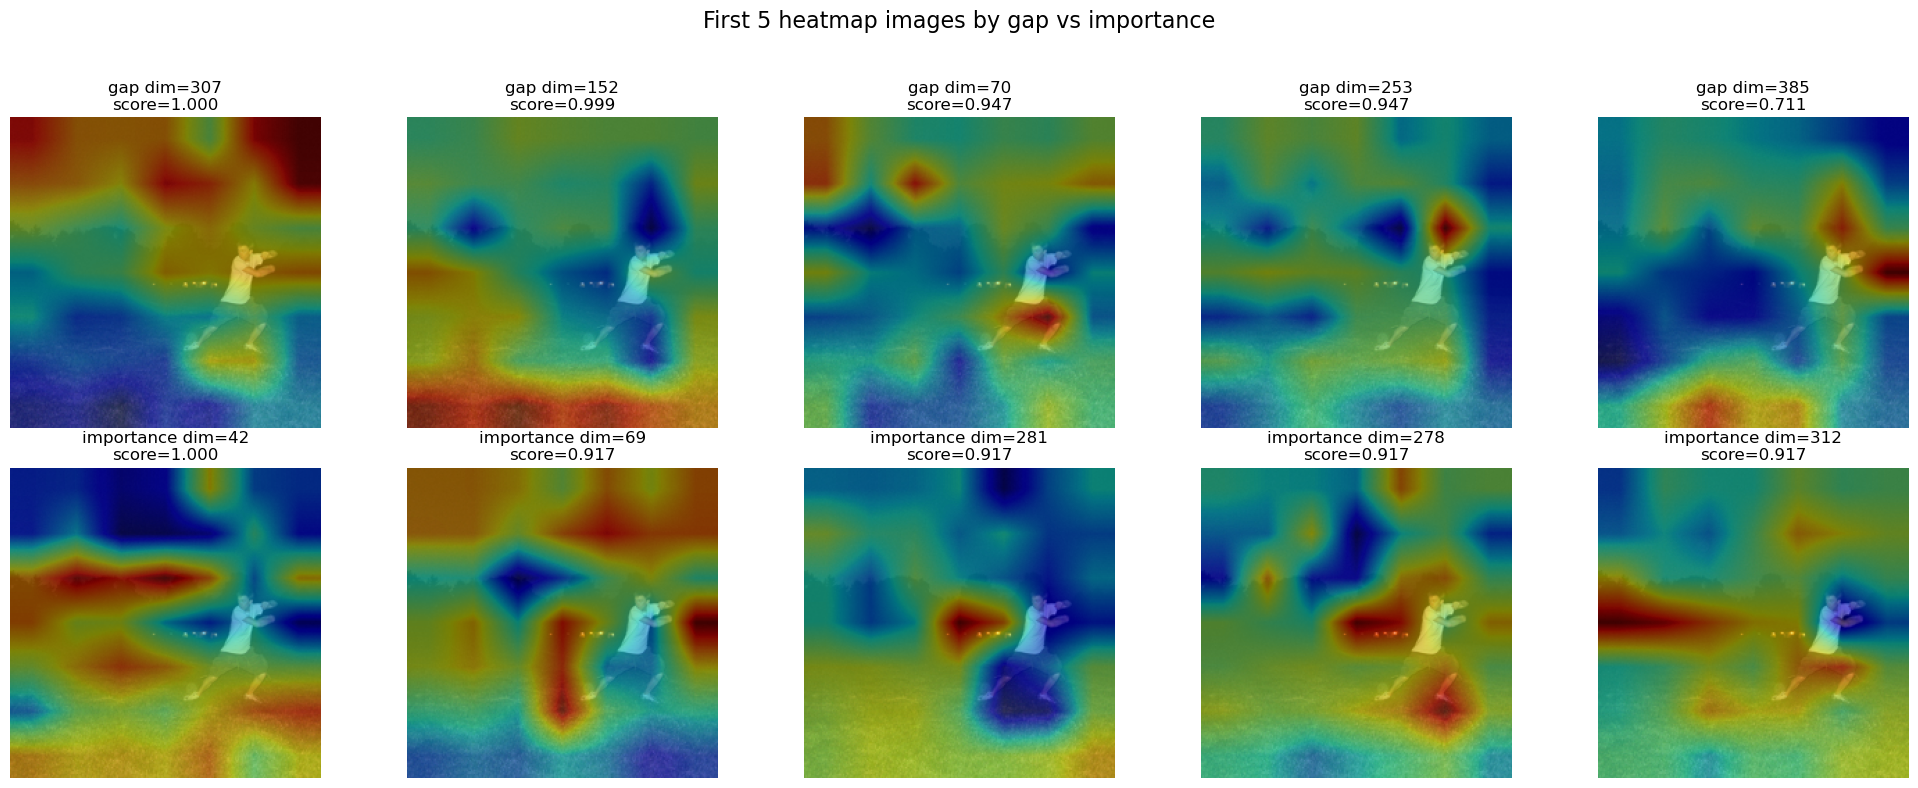

device          : cuda:1
text_features   : torch.Size([1, 512]) cuda:1
image_features  : torch.Size([1, 512]) cuda:1
cls_token       : torch.Size([1, 768]) cuda:1
spatial_tokens  : torch.Size([1, 49, 768]) cuda:1


In [31]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import open_clip

# -------------------------------
# 1) Force GPU 1
# -------------------------------
if torch.cuda.is_available():
    if torch.cuda.device_count() < 2:
        raise RuntimeError("GPU 1 requested, but only one CUDA device is available.")
    device = torch.device("cuda:1")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k",
)
model = model.to(device).eval()

# -------------------------------
# 2) Load image + text
# -------------------------------
daset_split = "val2017"
sample = "000000022892.jpg" # cat dog plant
# sample = "000000001761.jpg" # planes and bridge
# sample = "000000007281.jpg" # man and horses
# sample = "000000000885.jpg" # Tennis

daset_split = "train2017"
# sample = "000000000394.jpg" # dog and fresbee
# sample = "000000001025.jpg" # A dog sitting in a heart on a beach by ocean
# sample = "000000001098.jpg" # A dog sitting in a heart on a beach by ocean
# sample = "000000001108.jpg" # man on the skateboard
# sample = "000000001138.jpg" # living room
sample = "000000000589.jpg" # guy on the grass
# sample = "000000000502.jpg" # bear 


image_path = f"/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/{daset_split}/{sample}"
# text_list = ["a cat on a table and a dog"]
text_list = ["a cat"]

image_pil = Image.open(image_path).convert("RGB")
image_tensor = preprocess(image_pil).unsqueeze(0).to(device)
text_tokens = open_clip.tokenize(text_list).to(device)

# -------------------------------
# 3) Encode text
# -------------------------------
with torch.no_grad():
    text_features = model.encode_text(text_tokens)

# -------------------------------
# 4) Extract last-layer spatial tokens from image tower
# -------------------------------
with torch.no_grad():
    visual = model.visual
    x = visual._embeds(image_tensor)
    x = visual.transformer(x)
    x = visual.ln_post(x)

    cls_token = x[:, 0, :]
    spatial_tokens = x[:, 1:, :]

    pooled, _ = visual._pool(x)
    if visual.proj is not None:
        if isinstance(visual.proj, torch.nn.Linear):
            image_features = visual.proj(pooled)
        else:
            image_features = pooled @ visual.proj
    else:
        image_features = pooled

# -------------------------------
# 5) Build heatmaps for the first_K dimensions by gap / importance
# -------------------------------
B, N, C = spatial_tokens.shape
grid_size = int(N ** 0.5)

def build_dim_heatmap(dim_idx):
    heat = spatial_tokens[0, :, dim_idx].reshape(1, 1, grid_size, grid_size)
    heat = F.interpolate(
        heat,
        size=image_tensor.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )
    heat = heat[0, 0].detach().cpu()
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat.numpy()

# -------------------------------
# 6) De-normalize image for visualization
# -------------------------------
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1, 3, 1, 1)

img_vis = image_tensor * std + mean
img_vis = img_vis[0].detach().cpu().permute(1, 2, 0).numpy()
img_vis = np.clip(img_vis, 0, 1)

# -------------------------------
# 7) Show 2-row composition
# -------------------------------
fig, axes = plt.subplots(2, first_K, figsize=(4 * first_K, 8))
axes = np.array(axes, dtype=object).reshape(2, first_K)

for col, dim_idx in enumerate(top_gap_dims):
    ax = axes[0, col]
    heat = build_dim_heatmap(int(dim_idx))
    ax.imshow(img_vis)
    ax.imshow(heat, cmap="jet", alpha=0.5)
    ax.axis("off")
    ax.set_title(f"gap dim={int(dim_idx)}\nscore={ordered_gap_values[col]:.3f}")

for col, dim_idx in enumerate(top_imp_dims):
    ax = axes[1, col]
    heat = build_dim_heatmap(int(dim_idx))
    ax.imshow(img_vis)
    ax.imshow(heat, cmap="jet", alpha=0.5)
    ax.axis("off")
    ax.set_title(f"importance dim={int(dim_idx)}\nscore={ordered_imp_values[col]:.3f}")

axes[0, 0].set_ylabel("Top by gap", fontsize=12)
axes[1, 0].set_ylabel("Top by importance", fontsize=12)
fig.suptitle(f"First {first_K} heatmap images by gap vs importance", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# -------------------------------
# 8) Print shapes + devices
# -------------------------------
print("device          :", device)
print("text_features   :", text_features.shape, text_features.device)
print("image_features  :", image_features.shape, image_features.device)
print("cls_token       :", cls_token.shape, cls_token.device)
print("spatial_tokens  :", spatial_tokens.shape, spatial_tokens.device)


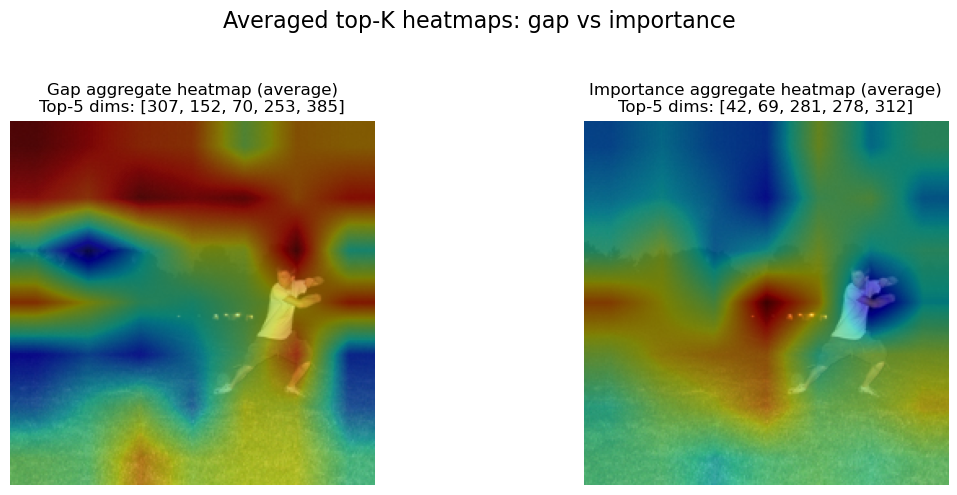

gap dims        : [307, 152, 70, 253, 385]
importance dims : [42, 69, 281, 278, 312]


In [32]:
# Aggregate the top-K dimension heatmaps into 2 comparison images
def aggregate_heatmap_v2(dim_indices):
    heatmaps = [build_dim_heatmap(int(dim_idx)) for dim_idx in dim_indices]
    agg = np.mean(np.stack(heatmaps, axis=0), axis=0)
    agg = (agg - agg.min()) / (agg.max() - agg.min() + 1e-8)
    return agg


gap_heat_avg = aggregate_heatmap_v2(top_gap_dims)
imp_heat_avg = aggregate_heatmap_v2(top_imp_dims)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_vis)
axes[0].imshow(gap_heat_avg, cmap="jet", alpha=0.5)
axes[0].axis("off")
axes[0].set_title(
    f"Gap aggregate heatmap (average)\nTop-{first_K} dims: {[int(d) for d in top_gap_dims]}"
)

axes[1].imshow(img_vis)
axes[1].imshow(imp_heat_avg, cmap="jet", alpha=0.5)
axes[1].axis("off")
axes[1].set_title(
    f"Importance aggregate heatmap (average)\nTop-{first_K} dims: {[int(d) for d in top_imp_dims]}"
)

fig.suptitle("Averaged top-K heatmaps: gap vs importance", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print("gap dims        :", [int(d) for d in top_gap_dims])
print("importance dims :", [int(d) for d in top_imp_dims])

In [25]:
# For the sample chosen and the split chosen shoe the caption from the dataset
import json
from pathlib import Path

dataset_root = Path("/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco")
annotations_path = dataset_root / "annotations" / f"captions_{daset_split}.json"

if not annotations_path.exists():
    raise FileNotFoundError(f"Could not find annotations file: {annotations_path}")

image_id = int(Path(sample).stem)

with open(annotations_path, "r") as f:
    payload = json.load(f)

captions = [
    ann["caption"]
    for ann in payload["annotations"]
    if int(ann["image_id"]) == image_id
]

if not captions:
    raise ValueError(f"No captions found for image_id={image_id} in {annotations_path}")

print(f"Split      : {daset_split}")
print(f"Sample     : {sample}")
print(f"Image ID   : {image_id}")
print(f"JSON file  : {annotations_path}")
print(f"text_list  : {text_list}")
print(f"# captions : {len(captions)}")
print()

for idx, caption in enumerate(captions, start=1):
    print(f"{idx}. {caption}")


Split      : train2017
Sample     : 000000000502.jpg
Image ID   : 502
JSON file  : /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/annotations/captions_train2017.json
text_list  : ['a cat']
# captions : 5

1. A furry, black bear standing in a rocky, weedy, area in the wild.
2. a black bear that is standing next to water
3. a close up of a bear on a hill near a body of water 
4. A black bear stands in the wild amongst dead grass
5. there is a black bear climbing the side of a mountain
